In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
import os

print(os.getcwd())

C:\Users\madhu


In [3]:
import os

print(os.listdir()) 

['.arduinoIDE', '.bash_history', '.cache', '.claude', '.codeium', '.config', '.copilot', '.cursor', '.git', '.git-credentials', '.git-for-windows-updater', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.local', '.matplotlib', '.ms-ad', '.node_repl_history', '.streamlit', '.trae', '.vscode', '05_advanced_analytics.ipynb', 'AppData', 'Application Data', 'bluestock_mf.db', 'C++', 'Contacts', 'Cookies', 'dashboard', 'data', 'data_ingestion.ipynb', 'day2_data_cleaning.ipynb', 'Documents', 'Downloads', 'EDA_Analysis.ipynb', 'Favorites', 'Links', 'Local Settings', 'Music', 'mutual_fund_analytics', 'My Documents', 'NetHood', 'New folder', 'node_modules', 'notebooks', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{8f4b9a4f-f317-11ef-af71-8884ce204129}.TxR.0.regtrans-ms', 'NTUSER.DAT{8f4b9a4f-f317-11ef-af71-8884ce204129}.TxR.0.regtrans-ms.cnpf', 'NTUSER.DAT{8f4b9a4f-f317-11ef-af71-8884ce204129}.TxR.1.regtrans-ms', 'NTUSER.DAT{8f4b9a4f-f317-1

In [4]:
import os

print(os.listdir("mutual_fund_analytics"))

['.git', '.gitignore', 'bluestock_mf.db', 'dashboard', 'data', 'data_ingestion.py', 'live_nav_fetch.py', 'notebooks', 'reports', 'requirement.txt', 'requirements.txt', 'sql']


In [5]:
import os

print(os.listdir("mutual_fund_analytics/data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count (1).csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Axis_Bluechip.csv', 'HDFC_Top100_NAV.csv', 'ICICI_Bluechip.csv', 'Kotak_Bluechip.csv', 'Nippon_LargeCap.csv', 'SBI_Bluechip.csv']


In [6]:
print(os.listdir())

['.arduinoIDE', '.bash_history', '.cache', '.claude', '.codeium', '.config', '.copilot', '.cursor', '.git', '.git-credentials', '.git-for-windows-updater', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.local', '.matplotlib', '.ms-ad', '.node_repl_history', '.streamlit', '.trae', '.vscode', '05_advanced_analytics.ipynb', 'AppData', 'Application Data', 'bluestock_mf.db', 'C++', 'Contacts', 'Cookies', 'dashboard', 'data', 'data_ingestion.ipynb', 'day2_data_cleaning.ipynb', 'Documents', 'Downloads', 'EDA_Analysis.ipynb', 'Favorites', 'Links', 'Local Settings', 'Music', 'mutual_fund_analytics', 'My Documents', 'NetHood', 'New folder', 'node_modules', 'notebooks', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{8f4b9a4f-f317-11ef-af71-8884ce204129}.TxR.0.regtrans-ms', 'NTUSER.DAT{8f4b9a4f-f317-11ef-af71-8884ce204129}.TxR.0.regtrans-ms.cnpf', 'NTUSER.DAT{8f4b9a4f-f317-11ef-af71-8884ce204129}.TxR.1.regtrans-ms', 'NTUSER.DAT{8f4b9a4f-f317-1

In [8]:
import pandas as pd
import numpy as np

nav = pd.read_csv("mutual_fund_analytics/data/raw/02_nav_history.csv")
scheme = pd.read_csv("mutual_fund_analytics/data/raw/07_scheme_performance.csv")

In [9]:
print(nav.head())

print(nav.columns)

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
Index(['amfi_code', 'date', 'nav'], dtype='object')


In [10]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [12]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [13]:
var_report = (
    nav.groupby('amfi_code')['daily_return']
       .apply(lambda x: pd.Series({
           'VaR_95': x.quantile(0.05),
           'CVaR_95': x[x <= x.quantile(0.05)].mean()
       }))
       .unstack()
       .reset_index()
)

var_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [15]:
scheme.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [17]:
var_report = var_report.merge(
    scheme[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

var_report = var_report[['amfi_code', 'scheme_name', 'VaR_95', 'CVaR_95']]

var_report.head()

,amfi_code,scheme_name,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [18]:
var_report.to_csv("var_cvar_report.csv", index=False)

print("CSV Saved Successfully!")

CSV Saved Successfully!


In [19]:
## Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR)

In [20]:
##task 2
scheme[scheme['scheme_name'].str.contains(
    'SBI|Axis|ICICI|Kotak|Nippon',
    case=False,
    na=False
)][['amfi_code','scheme_name']]

,amfi_code,scheme_name
0,119551,SBI Bluechip Fund - Regular Plan - Growth
1,119552,SBI Bluechip Fund - Direct Plan - Growth
2,119598,SBI Small Cap Fund - Regular Plan - Growth
3,119599,SBI Small Cap Fund - Direct Plan - Growth
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth
10,120503,ICICI Pru Bluechip Fund - Regular - Growth
11,120504,ICICI Pru Bluechip Fund - Direct - Growth
12,120505,ICICI Pru Midcap Fund - Regular - Growth
13,120506,ICICI Pru Value Discovery Fund - Regular - Growth
14,120507,ICICI Pru Liquid Fund - Regular - Growth


In [21]:
funds = [119551, 120503, 118632, 120841, 119092]

rolling_data = nav[nav['amfi_code'].isin(funds)].copy()

rolling_data.head()

,amfi_code,date,nav,daily_return
17250,118632,2022-01-03,42.8339,NaN
17251,118632,2022-01-04,42.8033,-0.000714
17252,118632,2022-01-05,43.0564,0.005913
17253,118632,2022-01-06,43.2088,0.003540
17254,118632,2022-01-07,42.9585,-0.005793


In [22]:
rolling_data['rolling_sharpe'] = (
    rolling_data.groupby('amfi_code')['daily_return']
    .transform(lambda x: (x.rolling(90).mean() / x.rolling(90).std()) * np.sqrt(252))
)

rolling_data.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
17250,118632,2022-01-03,42.8339,NaN,NaN
17251,118632,2022-01-04,42.8033,-0.000714,NaN
17252,118632,2022-01-05,43.0564,0.005913,NaN
17253,118632,2022-01-06,43.2088,0.003540,NaN
17254,118632,2022-01-07,42.9585,-0.005793,NaN


In [23]:
rolling_data = rolling_data.merge(
    scheme[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

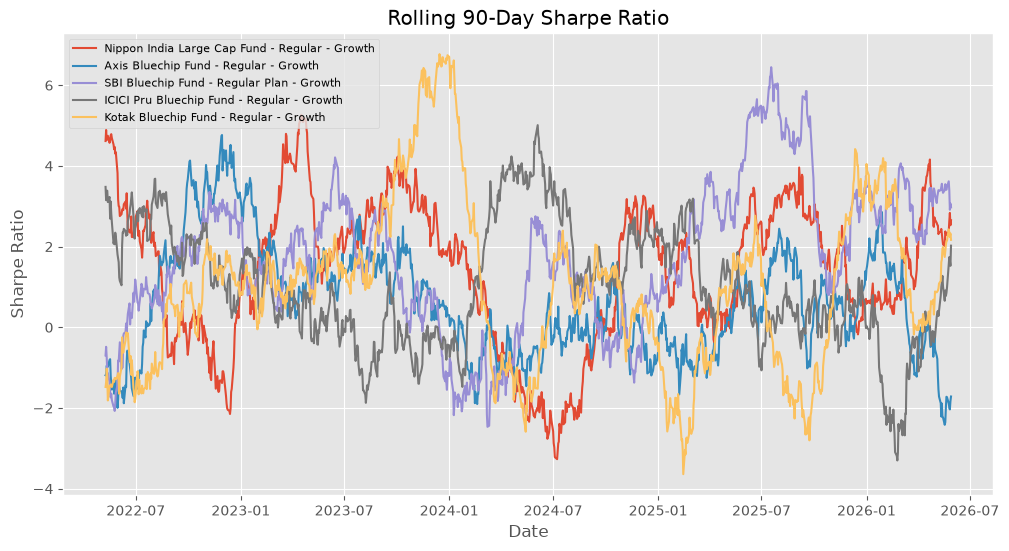

In [24]:
plt.figure(figsize=(12,6))

for fund in rolling_data['scheme_name'].unique():
    temp = rolling_data[rolling_data['scheme_name'] == fund]
    plt.plot(temp['date'], temp['rolling_sharpe'], label=fund)

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(fontsize=8)
plt.grid(True)

plt.savefig("rolling_sharpe_chart.png", dpi=300)

plt.show()

In [25]:
scheme[scheme['scheme_name'].str.contains("Axis", case=False)][['amfi_code','scheme_name']]


,amfi_code,scheme_name
24,119092,Axis Bluechip Fund - Regular - Growth
25,119093,Axis Bluechip Fund - Direct - Growth
26,119094,Axis Midcap Fund - Regular - Growth
27,119095,Axis Small Cap Fund - Regular - Growth


In [26]:
# task 3


In [27]:
investor = pd.read_csv("mutual_fund_analytics/data/raw/08_investor_transactions.csv")

In [28]:
investor.head()
print(investor.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [29]:
investor['transaction_date'] = pd.to_datetime(investor['transaction_date'])

In [30]:
first_transaction = (
    investor.groupby('investor_id')['transaction_date']
    .min()
    .dt.year
)

investor = investor.merge(
    first_transaction.rename('cohort_year'),
    on='investor_id'
)

In [31]:
print(investor.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_year'],
      dtype='object')


In [33]:
investor['transaction_date'] = pd.to_datetime(investor['transaction_date'])

In [34]:
first_txn = investor.groupby('investor_id')['transaction_date'].min()

cohort = first_txn.dt.year.rename('cohort_year')

investor = investor.merge(cohort, on='investor_id')

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [35]:
sip = investor[investor['transaction_type'] == 'SIP']

avg_sip = (
    sip.groupby('cohort_year')['amount_inr']
    .mean()
    .reset_index(name='Average_SIP')
)

avg_sip

,cohort_year,Average_SIP
0,2024,10996.885825
1,2025,13505.209581


In [36]:
total_investment = (
    investor.groupby('cohort_year')['amount_inr']
    .sum()
    .reset_index(name='Total_Invested')
)

total_investment

,cohort_year,Total_Invested
0,2024,3491125187
1,2025,30455243


In [37]:
top_fund = (
    investor.groupby(['cohort_year','amfi_code'])
    .size()
    .reset_index(name='Count')
)

top_fund = (
    top_fund.sort_values(
        ['cohort_year','Count'],
        ascending=[True,False]
    )
    .groupby('cohort_year')
    .first()
    .reset_index()
)

top_fund

,cohort_year,amfi_code,Count
0,2024,148568,874
1,2025,119599,12


In [39]:
top_fund = top_fund.merge(
    scheme[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

top_fund

,cohort_year,amfi_code,Count,scheme_name_x,scheme_name_y
0,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,119599,12,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth


In [43]:
print(top_fund.columns)

Index(['cohort_year', 'amfi_code', 'Count', 'scheme_name_x', 'scheme_name_y'], dtype='object')


In [44]:
cohort_report = (
    avg_sip
    .merge(total_investment, on='cohort_year')
    .merge(
        top_fund[['cohort_year', 'scheme_name_y']],
        on='cohort_year'
    )
)

cohort_report = cohort_report.rename(
    columns={'scheme_name_y': 'Top_Fund'}
)

cohort_report

,cohort_year,Average_SIP,Total_Invested,Top_Fund
0,2024,10996.885825,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.209581,30455243,SBI Small Cap Fund - Direct Plan - Growth


In [45]:
cohort_report.to_csv("cohort_analysis_report.csv", index=False)

print("Cohort Analysis Completed!")

Cohort Analysis Completed!


In [46]:
top_fund = top_fund.rename(columns={'scheme_name_y':'scheme_name'})
top_fund = top_fund.drop(columns=['scheme_name_x'])

top_fund.head()

,cohort_year,amfi_code,Count,scheme_name
0,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,119599,12,SBI Small Cap Fund - Direct Plan - Growth


In [47]:
cohort_report = (
    avg_sip
    .merge(total_investment, on='cohort_year')
    .merge(top_fund[['cohort_year','scheme_name']], on='cohort_year')
)

In [48]:
sip = investor[investor['transaction_type'] == 'SIP'].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [49]:
sip['transaction_date'] = pd.to_datetime(sip['transaction_date'])

sip = sip.sort_values(['investor_id', 'transaction_date'])

In [50]:
sip = sip.groupby('investor_id').filter(lambda x: len(x) >= 6)

print("Number of investors:", sip['investor_id'].nunique())

Number of investors: 1362


In [51]:
sip['gap_days'] = (
    sip.groupby('investor_id')['transaction_date']
       .diff()
       .dt.days
)

sip.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0
28749,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0
31897,INV000004,2025-05-17,119599,SIP,2110,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,49.0
9329,INV000008,2024-05-27,101206,SIP,8061,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,2024,NaN
11113,INV000008,2024-06-23,102887,SIP,55850,Punjab,Amritsar,B30,26-35,Female,18.6,Net Banking,Verified,2024,27.0
21549,INV000008,2024-12-05,100025,SIP,425,Punjab,Amritsar,B30,26-35,Female,18.6,UPI,Verified,2024,165.0
24389,INV000008,2025-01-18,119552,SIP,458,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,2024,44.0


In [52]:
sip_gap = (
    sip.groupby('investor_id')['gap_days']
       .mean()
       .reset_index(name='Average_Gap_Days')
)

sip_gap.head()

,investor_id,Average_Gap_Days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [53]:
sip_gap['Status'] = np.where(
    sip_gap['Average_Gap_Days'] > 35,
    'At-Risk',
    'Active'
)

sip_gap.head()

,investor_id,Average_Gap_Days,Status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk


In [54]:
sip_gap.to_csv("sip_continuity_report.csv", index=False)

print("SIP Continuity Report Saved!")

SIP Continuity Report Saved!


In [57]:
## SIP Continuity Analysis

##SIP Continuity Analysis evaluates the consistency of systematic investment plans by measuring the average time gap between consecutive SIP transactions. Investors with an average gap exceeding 35 days are classified as **At-Risk**, helping identify potential discontinuation of investments.